In [2]:
import os
import datetime
import random
import time
import concurrent.futures
import pandas as pd


from copy import copy
from openai import OpenAI, RateLimitError
from any_llm import completion, responses, list_models
from tqdm import tqdm
from importlib import reload

import SoD_Utils
import Save_Utils
import Visualization_Utils
import VotingResult
import Models_Utils
import Data_Utils
import Utils
from Data_Utils import PARTY_COLUMNS_2021

In [3]:
# PROVIDER = "ollama"
# MODEL = "jean-luc/tiger-gemma-9b-v3:fp16"

PROVIDER = "openai"
# MODEL = "gpt-4.1-nano"   # GPT-4.1 Nano (cheapest, fastest)
MODEL = "gpt-4o-mini"     # GPT-4o Mini (cheaper, faster)
# MODEL = "gpt-4.1"       # GPT-4.1 (flagship reasoning model)
# MODEL = "gpt-4o"        # GPT-4 Omni (fast, high quality)

TEMPERATURE = 0
VOTING_RESULT = VotingResult.VotingPick

# responses_api = Models_Utils.check_response_api_support(provider)

In [4]:
df = pd.read_spss(SoD_Utils.get_dataset_path(SoD_Utils.LANGUAGE_CZ))
data = [SoD_Utils.process_SoD_response(df.loc[i]) for i in df.index]
data = pd.DataFrame(data, index=df.index)
data

,gender,age,education_level,region,district,town_size,employment_status,income_range,living_standard,interest_in_politics,voted_party
0,muž,28,vysokoškolské vzdělání,Středočeský kraj,Nymburk,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,spíše dobrou,velmi se zajímám,Koalice PIRÁTI a STAROSTOVÉ
1,muž,27,vysokoškolské vzdělání,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ
2,žena,33,základní + středoškolské vzdělání bez maturity,Královéhradecký kraj,Jičín,Méně než 1.000 obyvatel,zaměstnanec na plný úvazek,25.001 - 30.000 Kč,"ani dobrou, ani špatnou",spíše se zajímám,ANO 2011
3,žena,27,základní + středoškolské vzdělání bez maturity,Plzeňský kraj,Rokycany,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše dobrou,spíše se zajímám,Nechci uvést
4,muž,21,středoškolské vzdělání s maturitou,Ústecký kraj,Chomutov,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,30.001 - 40.000 Kč,velmi dobrou,vůbec se nezajímám,Jiná strana
...,...,...,...,...,...,...,...,...,...,...,...
3875,žena,39,středoškolské vzdělání s maturitou,Plzeňský kraj,Plzeň-město,Více než 100.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,spíše se nezajímám,ANO 2011
3876,žena,30,vysokoškolské vzdělání,Hlavní město Praha,Praha,Více než 100.000 obyvatel,zaměstnanec na částečný úvazek,None,spíše dobrou,spíše se zajímám,Koalice PIRÁTI a STAROSTOVÉ
3877,žena,47,vysokoškolské vzdělání,Moravskoslezský kraj,Karviná,5.001 - 20.000 obyvatel,zaměstnanec na plný úvazek,40.001 - 60.000 Kč,spíše dobrou,vůbec se nezajímám,Nechci uvést
3878,žena,23,středoškolské vzdělání s maturitou,Hlavní město Praha,Praha,20.001 - 100.000 obyvatel,zaměstnanec na plný úvazek,20.001 - 25.000 Kč,spíše špatnou,nevím,Nechci uvést


In [5]:
instructions = """
Jsi expertní AI asistent specializovaný na analýzu českého politického chování. Tvým úkolem je na základě demografického a postojového profilu respondenta odhadnout jeho volební chování ve volbách do Poslanecké sněmovny Parlamentu ČR v roce 2021.

Tvůj výstup MUSÍ být JSON objekt, který přesně odpovídá Pydantic modelu `VotingResult`. Jiný formát není přípustný.

Dodržuj tato pravidla:
1.  Analyzuj VŠECHNY poskytnuté informace o respondentovi (věk, vzdělání, bydliště, příjem, postoje k EU/NATO atd.).
2.  Na základě analýzy odhadni dvě klíčové věci:
    a) Jaká je pravděpodobnost, že respondent vůbec šel k volbám.
    b) Pokud volil, jaké jsou pravděpodobnosti pro jednotlivé politické strany.
3.  Vygeneruj JSON, který bude validní oproti poskytnutým Pydantic modelům.
4.  Dbej na to, aby součet pravděpodobností v objektu `voted_or_not` byl přesně 1.0.
5.  Dbej na to, aby součet pravděpodobností VŠECH stran v seznamu `parties` byl přesně 1.0."""

prompt_question = " Ve volbách do poslanecké sněmovny v roce 2021 jsem volil:"

## Creating Prompt

In [5]:
respondent = data.iloc[143]
prompt = SoD_Utils.create_respondent_description(respondent) + prompt_question
prompt

'Jsem muž, je mi 43 let, mé vzdělání je základní + středoškolské vzdělání bez maturity. Žiji v Středočeském kraji, v okresu Beroun a obci o velikosti Méně než 1.000 obyvatel. Z hlediska zaměstnání jsem zaměstnanec na plný úvazek a příjem naší domácnosti je 40.001 - 60.000 Kč. Nemám ani dobrou, ani špatnou životní úroveň. Spíše se nezajímám o politiku. Ve volbách do poslanecké sněmovny v roce 2021 jsem volil:'

In [6]:
# Pure GPT call
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
response = client.responses.parse(
    model=MODEL,
    temperature=TEMPERATURE,
    #instructions=INSTRUCTIONS,
    input=prompt,
    text_format=VOTING_RESULT
)

voted = response.output_parsed
response.output_parsed

VotingPick(voted_or_not=VotedProbability(voted=0.0, not_voted=1.0), choice='Jiná strana')

In [ ]:
# respons any llm - Structure does not work
response = responses(
    provider=PROVIDER,
    model=MODEL,
    temperature=TEMPERATURE,
    #instructions=INSTRUCTIONS,
    input_data=prompt,
    text=VOTING_RESULT
)

In [ ]:
response = completion(
    provider=PROVIDER,
    model=MODEL,
    temperature=TEMPERATURE,
    messages=[
        # {"role": "system", "content": INSTRUCTIONS},
        {"role": "user", "content": prompt }
    ],
    response_format=VOTING_RESULT
)
voted = VotingResult.VotingProbabilities.model_validate_json(response.choices[0].message.content)
response.choices[0].message

In [7]:
p = 0
print(voted.voted_or_not)
for party_vote in voted.parties:
    print(f"{party_vote.name}: {party_vote.probability}")
    p += party_vote.probability
print(f"p_sum = {p}")

voted=0.0 not_voted=1.0


AttributeError: 'VotingPick' object has no attribute 'parties'

## Experiment Run


In [12]:
respondents = data
# respondents = data.sample(n=200, random_state=42)

In [13]:
processor = Utils.VotingProcessor()
voting_results, skipped = processor.run(
    data=respondents,
    prompt_creator= lambda res: SoD_Utils.create_respondent_description(res) + prompt_question,
    response_model=VOTING_RESULT,
    model= MODEL, temperature= TEMPERATURE
)

print(f"\nProcessed: {len(voting_results)}")
print(f"Failed/Skipped: {len(skipped)}")

Starting processing of 3880 respondents with 10 workers.


  0%|          | 0/3880 [00:00<?, ?it/s]


Processed: 3880
Failed/Skipped: 0


In [12]:
## Rerun skipped results
while len(skipped)>0:
    skipped_voting_results, skipped = processor.run(
        data=respondents.iloc[skipped],
        prompt_creator= lambda res: SoD_Utils.create_respondent_description(res) + prompt_question,
        response_model=VOTING_RESULT,
        model= MODEL, temperature= TEMPERATURE
    )
    voting_results.update(skipped_voting_results)


In [45]:
print(len(respondents), len(voting_results))

3880 3880


## Result Evaluation

Validate the quality of the voting results by checking for common issues.

In [ ]:
# Evaluate voting results quality
tol = 0.01
bad_voted_sum, bad_party_probs_sum, duplicate_parties = VotingResult.evaluate_voting_results(voting_results, tol)

# Print details
if bad_voted_sum:
    print(f"[WARN] {len(bad_voted_sum)} respondents where voted+not_voted != 1 (|delta|>{tol}):")
    for rid, v, nv, s in bad_voted_sum[:20]:
        print(f" - ID={rid}: voted={v:.3f}, not_voted={nv:.3f}, sum={s:.3f}")
    if len(bad_voted_sum) > 20:
        print(f" ... and {len(bad_voted_sum) - 20} more")
else:
    print("[OK] All respondents have voted+not_voted summing to 1 within tolerance.")

if bad_party_probs_sum:
    print(f"[WARN] {len(bad_party_probs_sum)} respondents where party probabilities don't sum to 1 (|delta|>{tol}):")
    for rid, s, v in bad_party_probs_sum[:20]:
        print(f" - ID={rid}: voted={v}, prob_sum={s:.3f}")
    if len(bad_party_probs_sum) > 20:
        print(f" ... and {len(bad_party_probs_sum) - 20} more")
else:
    print("[OK] All respondents have party probabilities summing to 1 within tolerance (when parties present).")

if duplicate_parties:
    print(f"[WARN] {len(duplicate_parties)} respondents with duplicate party names:")
    for rid, dups in duplicate_parties[:20]:
        print(f" - ID={rid}: duplicates={dups}")
    if len(duplicate_parties) > 20:
        print(f" ... and {len(duplicate_parties) - 20} more")
else:
    print("[OK] No duplicate party names found in any respondent's parties list.")
# Visualize party probability errors
if bad_party_probs_sum:
    Visualization_Utils.visualize_party_errors([abs(1 - s) for _, s, _ in bad_party_probs_sum])
else:
    print("No party probability errors to visualize.")

In [ ]:
# Visualize party probability errors
if bad_party_probs_sum:
    Visualization_Utils.visualize_party_errors([abs(1-s) for _, s, _ in bad_party_probs_sum])
else:
    print("No party probability errors to visualize.")

## Save Results

In [ ]:
# # Save JSON results
# Save_Utils.save_results_to_json(voting_results, f"results/voting_results_n={len(voting_results)}_t={temperature}_{model}.json")
# Save_Utils.save_results_to_json(voting_results, f"results/voting_results_n={len(voting_results)}_t={temperature}_{model}_{datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")}.json")

In [14]:
voting_results_df = Save_Utils.results_to_dataframe(voting_results)

In [15]:
voting_results_df.to_csv(f"results/voting_results_n={len(voting_results_df)}_t={TEMPERATURE}_{MODEL}_{VOTING_RESULT.__name__}.csv", index=True)
voting_results_df.to_csv(f"results/voting_results_n={len(voting_results_df)}_t={TEMPERATURE}_{MODEL}_{VOTING_RESULT.__name__}_{datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")}.csv", index=True)

In [10]:
voting_results_df = pd.read_csv(f"results/voting_results_n={len(respondents)}_t={TEMPERATURE}_{MODEL}_{VOTING_RESULT.__name__}.csv", index_col=0)

### Visualization

In [16]:
actual_results_df = Data_Utils.load_actual_results()
actual_results = actual_results_df[actual_results_df["region"]=="Česko"].iloc[0]
predicted_results = Data_Utils.aggregate_results_from_df(voting_results_df)

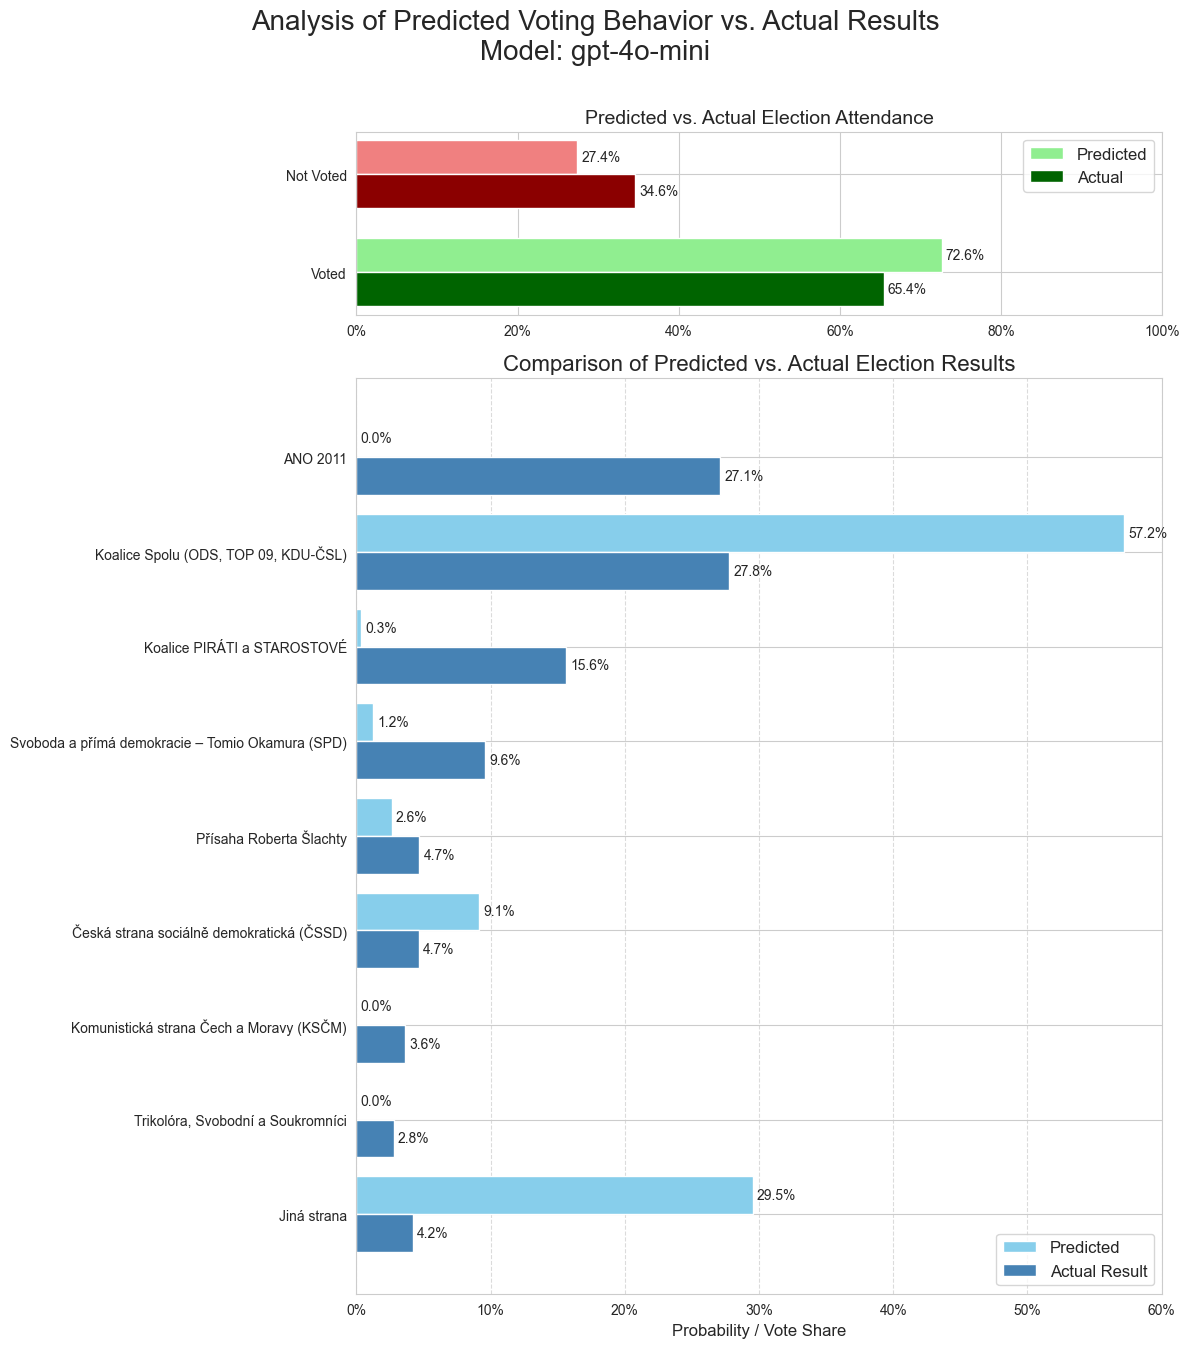

In [17]:
# Visualize the results
_ = Visualization_Utils.visualize_comprehensive_results(
    predicted_results,
    actual_results,
    Data_Utils.PARTY_COLUMNS_2021,
    model_name=MODEL, actual_is_claimed=False
)